# 🎶 Music Generation with Transformers

In this notebook, we'll walk through the steps required to train your own Transformer model to generate music in the style of the Bach cello suites

## Install Dependencies

In [1]:
!pip install tensorflow music21 matplotlib numpy tensorboard


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


## Download MIDI Files

In [2]:
import os
import glob
import urllib.request

base_dir = os.getcwd()
target_dir = os.path.join(base_dir, "bach-cello")
os.makedirs(target_dir, exist_ok=True)

files = [
    "cs1-1pre.mid", "cs1-2all.mid", "cs1-3cou.mid", "cs1-4sar.mid", "cs1-5men.mid", "cs1-6gig.mid",
    "cs2-1pre.mid", "cs2-2all.mid", "cs2-3cou.mid", "cs2-4sar.mid", "cs2-5men.mid", "cs2-6gig.mid",
    "cs3-1pre.mid", "cs3-2all.mid", "cs3-3cou.mid", "cs3-4sar.mid", "cs3-5bou.mid", "cs3-6gig.mid",
    "cs4-1pre.mid", "cs4-2all.mid", "cs4-3cou.mid", "cs4-4sar.mid", "cs4-5bou.mid", "cs4-6gig.mid",
    "cs5-1pre.mid", "cs5-2all.mid", "cs5-3cou.mid", "cs5-4sar.mid", "cs5-5gav.mid", "cs5-6gig.mid",
    "cs6-1pre.mid", "cs6-2all.mid", "cs6-3cou.mid", "cs6-4sar.mid", "cs6-5gav.mid", "cs6-6gig.mid"
]

base_url = "http://www.jsbach.net/midi/"

for fname in files:
    out_path = os.path.join(target_dir, fname)
    if not os.path.exists(out_path):
        try:
            urllib.request.urlretrieve(base_url + fname, out_path)
            print(f"Downloaded: {fname}")
        except Exception as e:
            print(f"Failed: {fname} -> {e}")

file_list = sorted(glob.glob(os.path.join(target_dir, "*.mid")))
print(f"\nFound {len(file_list)} MIDI files")


Found 36 MIDI files


## Imports & GPU Setup

In [3]:
import os
import sys
import glob
import time
import pickle as pkl
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Disable XLA JIT compilation to avoid CuDNN 9.3 requirement
# (RunPod container has CuDNN 9.1 which works with non-XLA TF kernels)
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'

import tensorflow as tf
tf.config.optimizer.set_jit(False)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f"GPU detected: {gpus[0].name}")
else:
    print("WARNING: No GPU detected.")

print(f"TensorFlow version: {tf.__version__}")
print(f"Python version: {sys.version}")

from tensorflow.keras import layers, models, losses, callbacks
import music21
from fractions import Fraction

I0000 00:00:1774505039.663688   11913 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU detected: /physical_device:GPU:0
TensorFlow version: 2.21.0
Python version: 3.11.10 (main, Sep  7 2024, 18:35:41) [GCC 11.4.0]


## Utility Functions (transformer_utils)

In [4]:
def parse_midi_files(file_list, parser, seq_len, parsed_data_path=None):
    notes = []
    durations = []

    for i, file in enumerate(file_list):
        print(i + 1, "Parsing %s" % file)
        score = parser.parse(file).chordify()

        notes.append("START")
        durations.append("0.0")

        for element in score.flat:
            note_name = None
            duration_name = None

            if isinstance(element, music21.key.Key):
                note_name = str(element.tonic.name) + ":" + str(element.mode)
                duration_name = "0.0"

            elif isinstance(element, music21.meter.TimeSignature):
                note_name = str(element.ratioString) + "TS"
                duration_name = "0.0"

            elif isinstance(element, music21.chord.Chord):
                note_name = element.pitches[-1].nameWithOctave
                duration_name = str(element.duration.quarterLength)

            elif isinstance(element, music21.note.Rest):
                note_name = str(element.name)
                duration_name = str(element.duration.quarterLength)

            elif isinstance(element, music21.note.Note):
                note_name = str(element.nameWithOctave)
                duration_name = str(element.duration.quarterLength)

            if note_name and duration_name:
                notes.append(note_name)
                durations.append(duration_name)
        print(f"{len(notes)} notes parsed")

    notes_list = []
    duration_list = []

    print(f"Building sequences of length {seq_len}")
    for i in range(len(notes) - seq_len):
        notes_list.append(" ".join(notes[i : (i + seq_len)]))
        duration_list.append(" ".join(durations[i : (i + seq_len)]))

    if parsed_data_path:
        os.makedirs(parsed_data_path, exist_ok=True)
        with open(os.path.join(parsed_data_path, "notes"), "wb") as f:
            pkl.dump(notes_list, f)
        with open(os.path.join(parsed_data_path, "durations"), "wb") as f:
            pkl.dump(duration_list, f)

    return notes_list, duration_list


def load_parsed_files(parsed_data_path):
    with open(os.path.join(parsed_data_path, "notes"), "rb") as f:
        notes = pkl.load(f)
    with open(os.path.join(parsed_data_path, "durations"), "rb") as f:
        durations = pkl.load(f)
    return notes, durations


def get_midi_note(sample_note, sample_duration):
    new_note = None

    if "TS" in sample_note:
        new_note = music21.meter.TimeSignature(sample_note.split("TS")[0])

    elif "major" in sample_note or "minor" in sample_note:
        tonic, mode = sample_note.split(":")
        new_note = music21.key.Key(tonic, mode)

    elif sample_note == "rest":
        new_note = music21.note.Rest()
        new_note.duration = music21.duration.Duration(
            float(Fraction(sample_duration))
        )
        new_note.storedInstrument = music21.instrument.Violoncello()

    elif "." in sample_note:
        notes_in_chord = sample_note.split(".")
        chord_notes = []
        for current_note in notes_in_chord:
            n = music21.note.Note(current_note)
            n.duration = music21.duration.Duration(
                float(Fraction(sample_duration))
            )
            n.storedInstrument = music21.instrument.Violoncello()
            chord_notes.append(n)
        new_note = music21.chord.Chord(chord_notes)

    elif sample_note != "START":
        new_note = music21.note.Note(sample_note)
        new_note.duration = music21.duration.Duration(
            float(Fraction(sample_duration))
        )
        new_note.storedInstrument = music21.instrument.Violoncello()

    return new_note


class SinePositionEncoding(tf.keras.layers.Layer):
    """Sinusoidal positional encoding layer (from Attention is All You Need)."""

    def __init__(self, max_wavelength=10000, **kwargs):
        super().__init__(**kwargs)
        self.max_wavelength = max_wavelength

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        seq_length = input_shape[-2]
        hidden_size = input_shape[-1]
        position = tf.cast(tf.range(seq_length), self.compute_dtype)
        min_freq = tf.cast(1 / self.max_wavelength, dtype=self.compute_dtype)
        timescales = tf.pow(
            min_freq,
            tf.cast(2 * (tf.range(hidden_size) // 2), self.compute_dtype)
            / tf.cast(hidden_size, self.compute_dtype),
        )
        angles = tf.expand_dims(position, 1) * tf.expand_dims(timescales, 0)
        cos_mask = tf.cast(tf.range(hidden_size) % 2, self.compute_dtype)
        sin_mask = 1 - cos_mask
        positional_encodings = (
            tf.sin(angles) * sin_mask + tf.cos(angles) * cos_mask
        )
        return tf.broadcast_to(positional_encodings, input_shape)

    def get_config(self):
        config = super().get_config()
        config.update({"max_wavelength": self.max_wavelength})
        return config

## 0. Parameters <a name="parameters"></a>

In [5]:
PARSE_MIDI_FILES = True
PARSED_DATA_PATH = "./parsed_data/"
DATASET_REPETITIONS = 1

SEQ_LEN = 50
EMBEDDING_DIM = 256
KEY_DIM = 256
N_HEADS = 5
DROPOUT_RATE = 0.3
FEED_FORWARD_DIM = 256
LOAD_MODEL = False

# optimization
EPOCHS = 5000
BATCH_SIZE = 256

GENERATE_LEN = 50

# Ensure output directories exist
for d in ["./parsed_data", "./output", "./checkpoint", "./models", "./logs"]:
    os.makedirs(d, exist_ok=True)

## 1. Prepare the Data

In [6]:
# file_list is already loaded from the download cell above
print(f"Found {len(file_list)} midi files")

Found 36 midi files


In [7]:
parser = music21.converter

In [8]:
example_score = (
    music21.converter.parse(file_list[1]).splitAtQuarterLength(12)[0].chordify()
)

In [9]:
example_score.show("text")

{0.0} <music21.metadata.Metadata object at 0x716ee90b4650>
{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.instrument.Violoncello 'Solo Cello: Solo Cello'>
    {0.0} <music21.instrument.Violoncello 'Violoncello'>
    {0.0} <music21.clef.BassClef>
    {0.0} <music21.tempo.MetronomeMark Quarter=250>
    {0.0} <music21.key.Key of G major>
    {0.0} <music21.meter.TimeSignature 4/4>
    {0.0} <music21.note.Rest 3.75ql>
    {3.5} <music21.tempo.MetronomeMark Quarter=77>
    {3.75} <music21.chord.Chord B3>
{4.0} <music21.stream.Measure 2 offset=4.0>
    {0.0} <music21.chord.Chord G2 D3 B3>
    {1.0} <music21.chord.Chord B3>
    {1.25} <music21.chord.Chord A3>
    {1.5} <music21.chord.Chord G3>
    {1.75} <music21.chord.Chord F#3>
    {2.0} <music21.chord.Chord G3>
    {2.25} <music21.chord.Chord D3>
    {2.5} <music21.chord.Chord E3>
    {2.75} <music21.chord.Chord F#3>
    {3.0} <music21.chord.Chord G3>
    {3.25} <music21.chord.Chord A3>
    {3.5} <music21.chord.Chord B3>
  

In [10]:
if PARSE_MIDI_FILES:
    notes, durations = parse_midi_files(
        file_list, parser, SEQ_LEN + 1, PARSED_DATA_PATH
    )
else:
    notes, durations = load_parsed_files(PARSED_DATA_PATH)

1 Parsing /workspace/bach-cello/cs1-1pre.mid
658 notes parsed
2 Parsing /workspace/bach-cello/cs1-2all.mid
1579 notes parsed
3 Parsing /workspace/bach-cello/cs1-3cou.mid
2399 notes parsed
4 Parsing /workspace/bach-cello/cs1-4sar.mid
2662 notes parsed
5 Parsing /workspace/bach-cello/cs1-5men.mid
3309 notes parsed
6 Parsing /workspace/bach-cello/cs1-6gig.mid
3735 notes parsed
7 Parsing /workspace/bach-cello/cs2-1pre.mid
4373 notes parsed
8 Parsing /workspace/bach-cello/cs2-2all.mid
5066 notes parsed
9 Parsing /workspace/bach-cello/cs2-3cou.mid
5807 notes parsed
10 Parsing /workspace/bach-cello/cs2-4sar.mid
6144 notes parsed
11 Parsing /workspace/bach-cello/cs2-5men.mid
6671 notes parsed
12 Parsing /workspace/bach-cello/cs2-6gig.mid
7406 notes parsed
13 Parsing /workspace/bach-cello/cs3-1pre.mid
8387 notes parsed
14 Parsing /workspace/bach-cello/cs3-2all.mid
9124 notes parsed
15 Parsing /workspace/bach-cello/cs3-3cou.mid
10113 notes parsed
16 Parsing /workspace/bach-cello/cs3-4sar.mid
104

In [11]:
example_notes = notes[658]
example_durations = durations[658]
print("\nNotes string\n", example_notes, "...")
print("\nDuration string\n", example_durations, "...")


Notes string
 START G:major 4/4TS rest B3 B3 B3 A3 G3 F#3 G3 D3 E3 F#3 G3 A3 B3 C4 D4 B3 G3 F#3 G3 E3 D3 C3 B2 C3 D3 E3 F#3 G3 A3 B3 C4 A3 G3 F#3 G3 E3 F#3 G3 A2 D3 F#3 G3 A3 B3 C4 A3 B3 ...

Duration string
 0.0 0.0 0.0 3.75 0.25 1.0 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 ...


## 2. Tokenize the data <a name="tokenize"></a>

In [12]:
def create_dataset(elements):
    ds = (
        tf.data.Dataset.from_tensor_slices(elements)
        .batch(BATCH_SIZE, drop_remainder=True)
        .shuffle(1000)
    )
    vectorize_layer = layers.TextVectorization(
        standardize=None, output_mode="int"
    )
    vectorize_layer.adapt(ds)
    vocab = vectorize_layer.get_vocabulary()
    return ds, vectorize_layer, vocab


notes_seq_ds, notes_vectorize_layer, notes_vocab = create_dataset(notes)
durations_seq_ds, durations_vectorize_layer, durations_vocab = create_dataset(
    durations
)
seq_ds = tf.data.Dataset.zip((notes_seq_ds, durations_seq_ds))

I0000 00:00:1774505056.248452   11913 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9


In [13]:
# Display the same example notes and durations converted to ints
example_tokenised_notes = notes_vectorize_layer(example_notes)
example_tokenised_durations = durations_vectorize_layer(example_durations)
print("{:10} {:10}".format("note token", "duration token"))
for i, (note_int, duration_int) in enumerate(
    zip(
        example_tokenised_notes.numpy()[:11],
        example_tokenised_durations.numpy()[:11],
    )
):
    print(f"{note_int:10}{duration_int:10}")

note token duration token
        37         9
        51         9
        42         9
        33        18
         9         2
         9         4
         9         2
         3         2
         2         2
        12         2
         2         2


In [14]:
notes_vocab_size = len(notes_vocab)
durations_vocab_size = len(durations_vocab)

# Display some token:note mappings
print(f"\nNOTES_VOCAB: length = {len(notes_vocab)}")
for i, note in enumerate(notes_vocab[:10]):
    print(f"{i}: {note}")

print(f"\nDURATIONS_VOCAB: length = {len(durations_vocab)}")
# Display some token:duration mappings
for i, note in enumerate(durations_vocab[:10]):
    print(f"{i}: {note}")


NOTES_VOCAB: length = 59
0: 
1: [UNK]
2: G3
3: A3
4: D3
5: F3
6: C4
7: D4
8: E3
9: B3

DURATIONS_VOCAB: length = 24
0: 
1: [UNK]
2: 0.25
3: 0.5
4: 1.0
5: 1/3
6: 0.75
7: 1/12
8: 1.5
9: 0.0


## 3. Create the Training Set <a name="create"></a>

In [15]:
# Create the training set of sequences and the same sequences shifted by one note
def prepare_inputs(notes, durations):
    notes = tf.expand_dims(notes, -1)
    durations = tf.expand_dims(durations, -1)
    tokenized_notes = notes_vectorize_layer(notes)
    tokenized_durations = durations_vectorize_layer(durations)
    x = (tokenized_notes[:, :-1], tokenized_durations[:, :-1])
    y = (tokenized_notes[:, 1:], tokenized_durations[:, 1:])
    return x, y


ds = seq_ds.map(prepare_inputs).repeat(DATASET_REPETITIONS)

In [16]:
example_input_output = ds.take(1).get_single_element()
print(example_input_output)

((<tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[ 2,  8,  5, ...,  4, 16, 11],
       [ 8,  5,  4, ..., 16, 11, 11],
       [ 5,  4,  8, ..., 11, 11,  4],
       ...,
       [32, 16, 13, ...,  6, 14, 10],
       [16, 13, 32, ..., 14, 10, 14],
       [13, 32, 30, ..., 10, 14, 13]], shape=(256, 50))>, <tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[4, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 3],
       [2, 2, 2, ..., 2, 3, 2],
       ...,
       [3, 3, 3, ..., 3, 4, 4],
       [3, 3, 3, ..., 4, 4, 4],
       [3, 3, 4, ..., 4, 4, 2]], shape=(256, 50))>), (<tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[ 8,  5,  4, ..., 16, 11, 11],
       [ 5,  4,  8, ..., 11, 11,  4],
       [ 4,  8, 13, ..., 11,  4,  8],
       ...,
       [16, 13, 32, ..., 14, 10, 14],
       [13, 32, 30, ..., 10, 14, 13],
       [32, 30, 18, ..., 14, 13, 10]], shape=(256, 50))>, <tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[2, 2, 2, ..., 2, 2, 3],
       [2, 2, 2, ..., 2,

## 5. Create the causal attention mask function <a name="causal"></a>

In [17]:
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], 0
    )
    return tf.tile(mask, mult)


np.transpose(causal_attention_mask(1, 10, 10, dtype=tf.int32)[0])

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=int32)

## 6. Create a Transformer Block layer <a name="transformer"></a>

In [18]:
class TransformerBlock(layers.Layer):
    def __init__(
        self,
        num_heads,
        key_dim,
        embed_dim,
        ff_dim,
        name,
        dropout_rate=DROPOUT_RATE,
    ):
        super(TransformerBlock, self).__init__(name=name)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = layers.MultiHeadAttention(
            num_heads, key_dim, output_shape=embed_dim
        )
        self.dropout_1 = layers.Dropout(self.dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(self.ff_dim, activation="relu")
        self.ffn_2 = layers.Dense(self.embed_dim)
        self.dropout_2 = layers.Dropout(self.dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        causal_mask = causal_attention_mask(
            batch_size, seq_len, seq_len, tf.bool
        )
        attention_output, attention_scores = self.attn(
            inputs,
            inputs,
            attention_mask=causal_mask,
            return_attention_scores=True,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1 + ffn_output), attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "key_dim": self.key_dim,
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

## 7. Create the Token and Position Embedding <a name="embedder"></a>

In [19]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            embeddings_initializer="he_uniform",
        )
        self.pos_emb = SinePositionEncoding()

    def call(self, x):
        embedding = self.token_emb(x)
        positions = self.pos_emb(embedding)
        return embedding + positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config

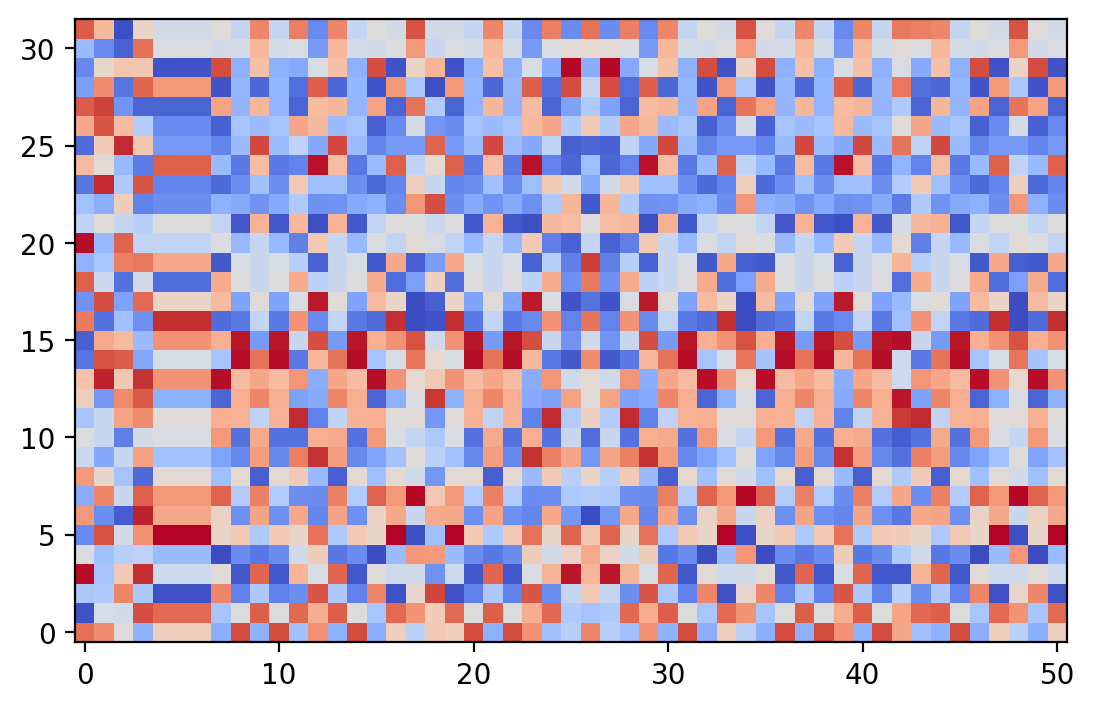

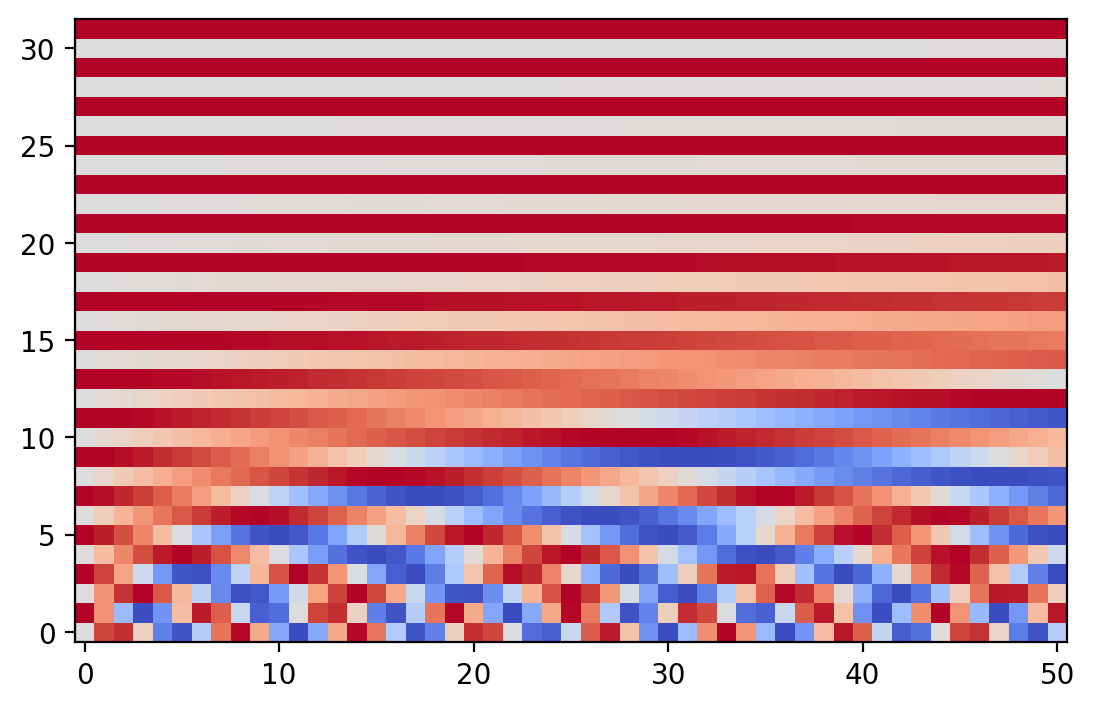

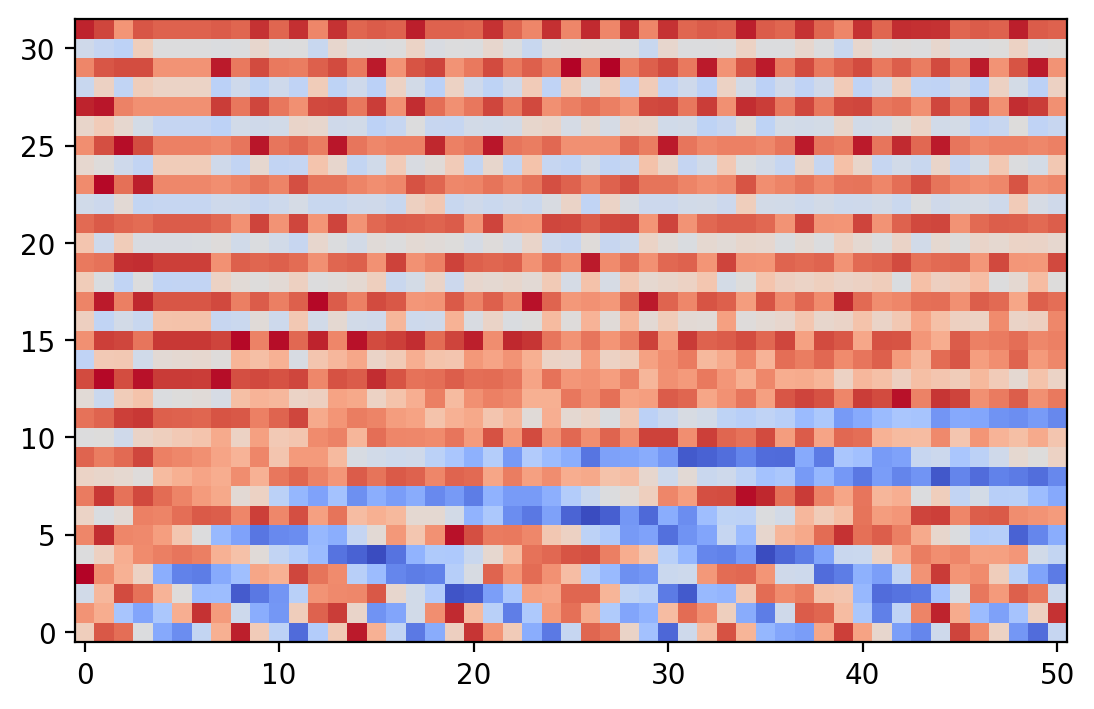

In [20]:
tpe = TokenAndPositionEmbedding(notes_vocab_size, 32)
token_embedding = tpe.token_emb(example_tokenised_notes)
position_embedding = tpe.pos_emb(token_embedding)
embedding = tpe(example_tokenised_notes)
plt.imshow(
    np.transpose(token_embedding),
    cmap="coolwarm",
    interpolation="nearest",
    origin="lower",
)
plt.show()
plt.imshow(
    np.transpose(position_embedding),
    cmap="coolwarm",
    interpolation="nearest",
    origin="lower",
)
plt.show()
plt.imshow(
    np.transpose(embedding),
    cmap="coolwarm",
    interpolation="nearest",
    origin="lower",
)
plt.show()

## 8. Build the Transformer model <a name="transformer_decoder"></a>

In [21]:
note_inputs = layers.Input(shape=(None,), dtype=tf.int32)
durations_inputs = layers.Input(shape=(None,), dtype=tf.int32)
note_embeddings = TokenAndPositionEmbedding(
    notes_vocab_size, EMBEDDING_DIM // 2
)(note_inputs)
duration_embeddings = TokenAndPositionEmbedding(
    durations_vocab_size, EMBEDDING_DIM // 2
)(durations_inputs)
embeddings = layers.Concatenate()([note_embeddings, duration_embeddings])
x, attention_scores = TransformerBlock(
    N_HEADS, KEY_DIM, EMBEDDING_DIM, FEED_FORWARD_DIM, name="attention"
)(embeddings)
note_outputs = layers.Dense(
    notes_vocab_size, activation="softmax", name="note_outputs"
)(x)
duration_outputs = layers.Dense(
    durations_vocab_size, activation="softmax", name="duration_outputs"
)(x)
model = models.Model(
    inputs=[note_inputs, durations_inputs],
    outputs=[note_outputs, duration_outputs],
)
model.compile(
    "adam",
    loss=[
        losses.SparseCategoricalCrossentropy(),
        losses.SparseCategoricalCrossentropy(),
    ],
    jit_compile=False,
)
att_model = models.Model(
    inputs=[note_inputs, durations_inputs], outputs=attention_scores
)

In [22]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 128) │      7,552 │ input_layer[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 128) │      3,072 │ input_layer_1[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 256) │          0 │ token_and_positi… │
│ (Concatenate)       │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, None,     │  1,447,424 │ concatenate[0][0] │
│ (TransformerBlock)  │ 256), (None, 5,   │            │                   │
│                     │ None, None)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ note_outputs        │ (None, None, 59)  │     15,163 │ attention[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration_outputs    │ (None, None, 24)  │      6,168 │ attention[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,479,379 (5.64 MB)

 Trainable params: 1,479,379 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
if LOAD_MODEL:
    model.load_weights("./checkpoint/checkpoint.weights.h5")

## 9. Train the Transformer <a name="train"></a>

In [24]:
# Create a MusicGenerator checkpoint
class MusicGenerator(callbacks.Callback):
    def __init__(self, index_to_note, index_to_duration, top_k=10):
        self.index_to_note = index_to_note
        self.note_to_index = {
            note: index for index, note in enumerate(index_to_note)
        }
        self.index_to_duration = index_to_duration
        self.duration_to_index = {
            duration: index for index, duration in enumerate(index_to_duration)
        }

    def sample_from(self, probs, temperature):
        probs = probs ** (1 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs), probs

    def get_note(self, notes, durations, temperature):
        sample_note_idx = 1
        while sample_note_idx == 1:
            sample_note_idx, note_probs = self.sample_from(
                notes[0][-1], temperature
            )
            sample_note = self.index_to_note[sample_note_idx]

        sample_duration_idx = 1
        while sample_duration_idx == 1:
            sample_duration_idx, duration_probs = self.sample_from(
                durations[0][-1], temperature
            )
            sample_duration = self.index_to_duration[sample_duration_idx]

        new_note = get_midi_note(sample_note, sample_duration)

        return (
            new_note,
            sample_note_idx,
            sample_note,
            note_probs,
            sample_duration_idx,
            sample_duration,
            duration_probs,
        )

    def generate(self, start_notes, start_durations, max_tokens, temperature):
        attention_model = models.Model(
            inputs=self.model.input,
            outputs=self.model.get_layer("attention").output,
        )
        attention_model.compile(jit_compile=False)

        start_note_tokens = [self.note_to_index.get(x, 1) for x in start_notes]
        start_duration_tokens = [
            self.duration_to_index.get(x, 1) for x in start_durations
        ]
        sample_note = None
        sample_duration = None
        info = []
        midi_stream = music21.stream.Stream()

        midi_stream.append(music21.clef.BassClef())

        for sample_note, sample_duration in zip(start_notes, start_durations):
            new_note = get_midi_note(sample_note, sample_duration)
            if new_note is not None:
                midi_stream.append(new_note)

        while len(start_note_tokens) < max_tokens:
            x1 = np.array([start_note_tokens])
            x2 = np.array([start_duration_tokens])
            notes, durations = self.model.predict([x1, x2], verbose=0)

            repeat = True

            while repeat:
                (
                    new_note,
                    sample_note_idx,
                    sample_note,
                    note_probs,
                    sample_duration_idx,
                    sample_duration,
                    duration_probs,
                ) = self.get_note(notes, durations, temperature)

                if (
                    isinstance(new_note, music21.chord.Chord)
                    or isinstance(new_note, music21.note.Note)
                    or isinstance(new_note, music21.note.Rest)
                ) and sample_duration == "0.0":
                    repeat = True
                else:
                    repeat = False

            if new_note is not None:
                midi_stream.append(new_note)

            _, att = attention_model.predict([x1, x2], verbose=0)

            info.append(
                {
                    "prompt": [start_notes.copy(), start_durations.copy()],
                    "midi": midi_stream,
                    "chosen_note": (sample_note, sample_duration),
                    "note_probs": note_probs,
                    "duration_probs": duration_probs,
                    "atts": att[0, :, -1, :],
                }
            )
            start_note_tokens.append(sample_note_idx)
            start_duration_tokens.append(sample_duration_idx)
            start_notes.append(sample_note)
            start_durations.append(sample_duration)

            if sample_note == "START":
                break

        return info

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 != 0:
            return
        info = self.generate(
            ["START"], ["0.0"], max_tokens=GENERATE_LEN, temperature=0.5
        )
        midi_stream = info[-1]["midi"].chordify()
        print(info[-1]["prompt"])
        midi_stream.write(
            "midi",
            fp=os.path.join(
                "./output",
                "output-" + str(epoch).zfill(4) + ".mid",
            ),
        )
        print(f"  Saved MIDI output for epoch {epoch}")

In [25]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
filepath="./checkpoint/checkpoint.weights.h5",
save_weights_only=True,
save_freq="epoch",
verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

# Tokenize starting prompt
music_generator = MusicGenerator(notes_vocab, durations_vocab)

In [26]:
model.fit(
    ds,
    epochs=EPOCHS,
    callbacks=[
        model_checkpoint_callback,
        tensorboard_callback,
        music_generator,
    ],
)

Epoch 1/5000
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - duration_outputs_loss: 2.1222 - loss: 5.7370 - note_outputs_loss: 3.6148[['START', np.str_('G3'), np.str_('G3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('F#3'), np.str_('G3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('G3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('G4'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('D3'), np.str_('B-3'), np.str_('G3'), np.str_('D3'), np.str_('G3'), np.str_('G3'), np.str_('B-3'), np.str_('G3'), np.str_('G3'), np.str_('G3'), np.str_('A3'), np.str_('G3'), np.str_('G3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('A2'), np.str_('F3')], ['0.0', np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - duration_outputs_loss: 0.5249 - loss: 1.0544 - note_outputs_loss: 0.5295
Epoch 4137/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - duration_outputs_loss: 0.5262 - loss: 1.0471 - note_outputs_loss: 0.5209
Epoch 4138/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - duration_outputs_loss: 0.5242 - loss: 1.0455 - note_outputs_loss: 0.5213
Epoch 4139/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - duration_outputs_loss: 0.5238 - loss: 1.0486 - note_outputs_loss: 0.5248
Epoch 4140/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - duration_outputs_loss: 0.5225 - loss: 1.0569 - note_outputs_loss: 0.5344
Epoch 4141/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - duration_outputs_loss: 0.5237 - loss: 1.0550 - note_outputs_loss: 0.5314
Epoch 4142/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - duration_outputs_loss: 0.5251 - loss: 1.0495 - note_outputs_loss: 0.5244
Epoch 4143/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - duration_outputs_loss: 0.

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - duration_outputs_loss: 0.5231 - loss: 1.0427 - note_outputs_loss: 0.5196
Epoch 4523/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - duration_outputs_loss: 0.5232 - loss: 1.0420 - note_outputs_loss: 0.5188
Epoch 4524/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - duration_outputs_loss: 0.5234 - loss: 1.0457 - note_outputs_loss: 0.5223
Epoch 4525/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - duration_outputs_loss: 0.5220 - loss: 1.0411 - note_outputs_loss: 0.5191
Epoch 4526/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - duration_outputs_loss: 0.5234 - loss: 1.0461 - note_outputs_loss: 0.5228
Epoch 4527/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - duration_outputs_loss: 0.5216 - loss: 1.0412 - note_outputs_loss: 0.5196
Epoch 4528/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - duration_outputs_loss: 0.5216 - loss: 1.0395 - note_outputs_loss: 0.5180
Epoch 4529/5000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - duration_outputs_loss: 0.

In [27]:
# Save the final model
model.save("./models/model.keras")

# 3. Generate music using the Transformer

In [28]:
info = music_generator.generate(
    ["START"], ["0.0"], max_tokens=50, temperature=0.5
)
midi_stream = info[-1]["midi"].chordify()
midi_stream.show("text")

{0.0} <music21.clef.BassClef>
{0.0} <music21.key.Key of E- major>
{0.0} <music21.meter.TimeSignature 4/4>
{0.0} <music21.note.Rest eighth>
{0.5} <music21.chord.Chord B-3>
{1.0} <music21.chord.Chord E-4>
{1.5} <music21.chord.Chord D4>
{2.0} <music21.chord.Chord C4>
{2.5} <music21.chord.Chord B-3>
{3.0} <music21.chord.Chord G#3>
{3.5} <music21.chord.Chord G3>
{4.0} <music21.chord.Chord G#3>
{4.5} <music21.chord.Chord B-3>
{5.0} <music21.chord.Chord G#3>
{5.5} <music21.chord.Chord G3>
{6.0} <music21.chord.Chord F3>
{6.5} <music21.chord.Chord E-3>
{7.0} <music21.chord.Chord D3>
{7.5} <music21.chord.Chord C3>
{8.0} <music21.chord.Chord B-2>
{8.5} <music21.chord.Chord C3>
{9.0} <music21.chord.Chord E-3>
{9.5} <music21.chord.Chord F3>
{10.0} <music21.chord.Chord G3>
{10.5} <music21.chord.Chord G#3>
{11.0} <music21.chord.Chord G3>
{11.5} <music21.chord.Chord F3>
{12.0} <music21.chord.Chord E-3>
{12.5} <music21.chord.Chord D3>
{13.0} <music21.chord.Chord E-3>
{13.5} <music21.chord.Chord F3>
{14

## Write music to MIDI file

In [29]:
timestr = time.strftime("%Y%m%d-%H%M%S")
midi_stream.write(
    "midi",
    fp=os.path.join(
        "./output",
        "output-" + timestr + ".mid",
    ),
)
print(f"Saved to ./output/output-{timestr}.mid")

Saved to ./output/output-20260326-082718.mid


## Note probabilities

In [30]:
max_pitch = 70
seq_len = len(info)
grid = np.zeros((max_pitch, seq_len), dtype=np.float32)

for j in range(seq_len):
    for i, prob in enumerate(info[j]["note_probs"]):
        try:
            pitch = music21.note.Note(notes_vocab[i]).pitch.midi
            grid[pitch, j] = prob
        except:
            pass  # Don't show key / time signatures

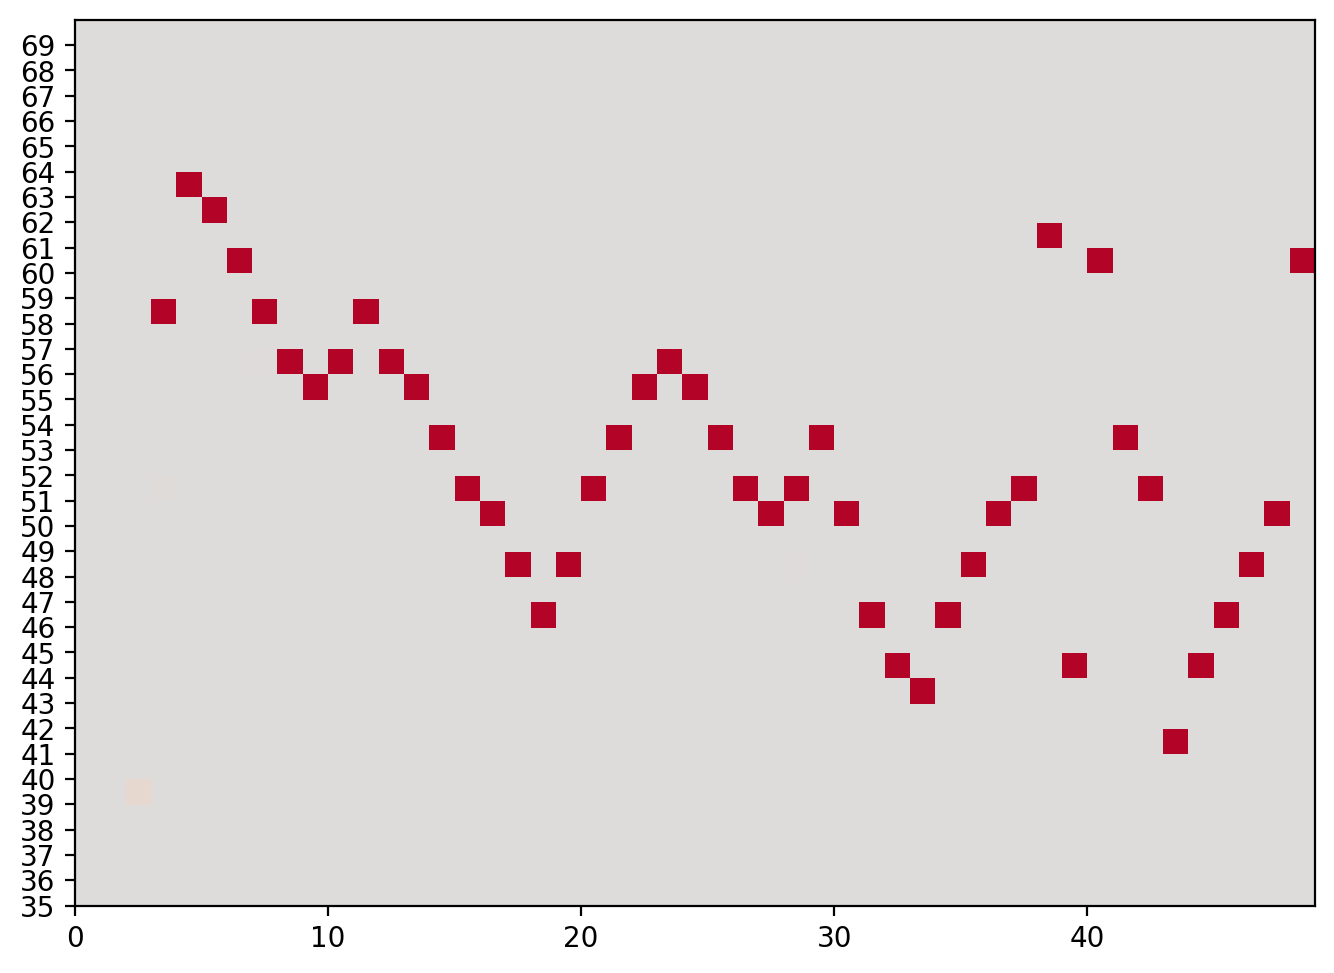

In [31]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_yticks([int(j) for j in range(35, 70)])
plt.imshow(
    grid[35:70, :],
    origin="lower",
    cmap="coolwarm",
    vmin=-0.5,
    vmax=0.5,
    extent=[0, seq_len, 35, 70],
)
plt.show()

## Attention Plot

In [32]:
plot_size = 20

att_matrix = np.zeros((plot_size, plot_size))
prediction_output = []
last_prompt = []

In [33]:
for j in range(plot_size):
    atts = info[j]["atts"].max(axis=0)
    att_matrix[: (j + 1), j] = atts
    prediction_output.append(info[j]["chosen_note"][0])
    last_prompt.append(info[j]["prompt"][0][-1])

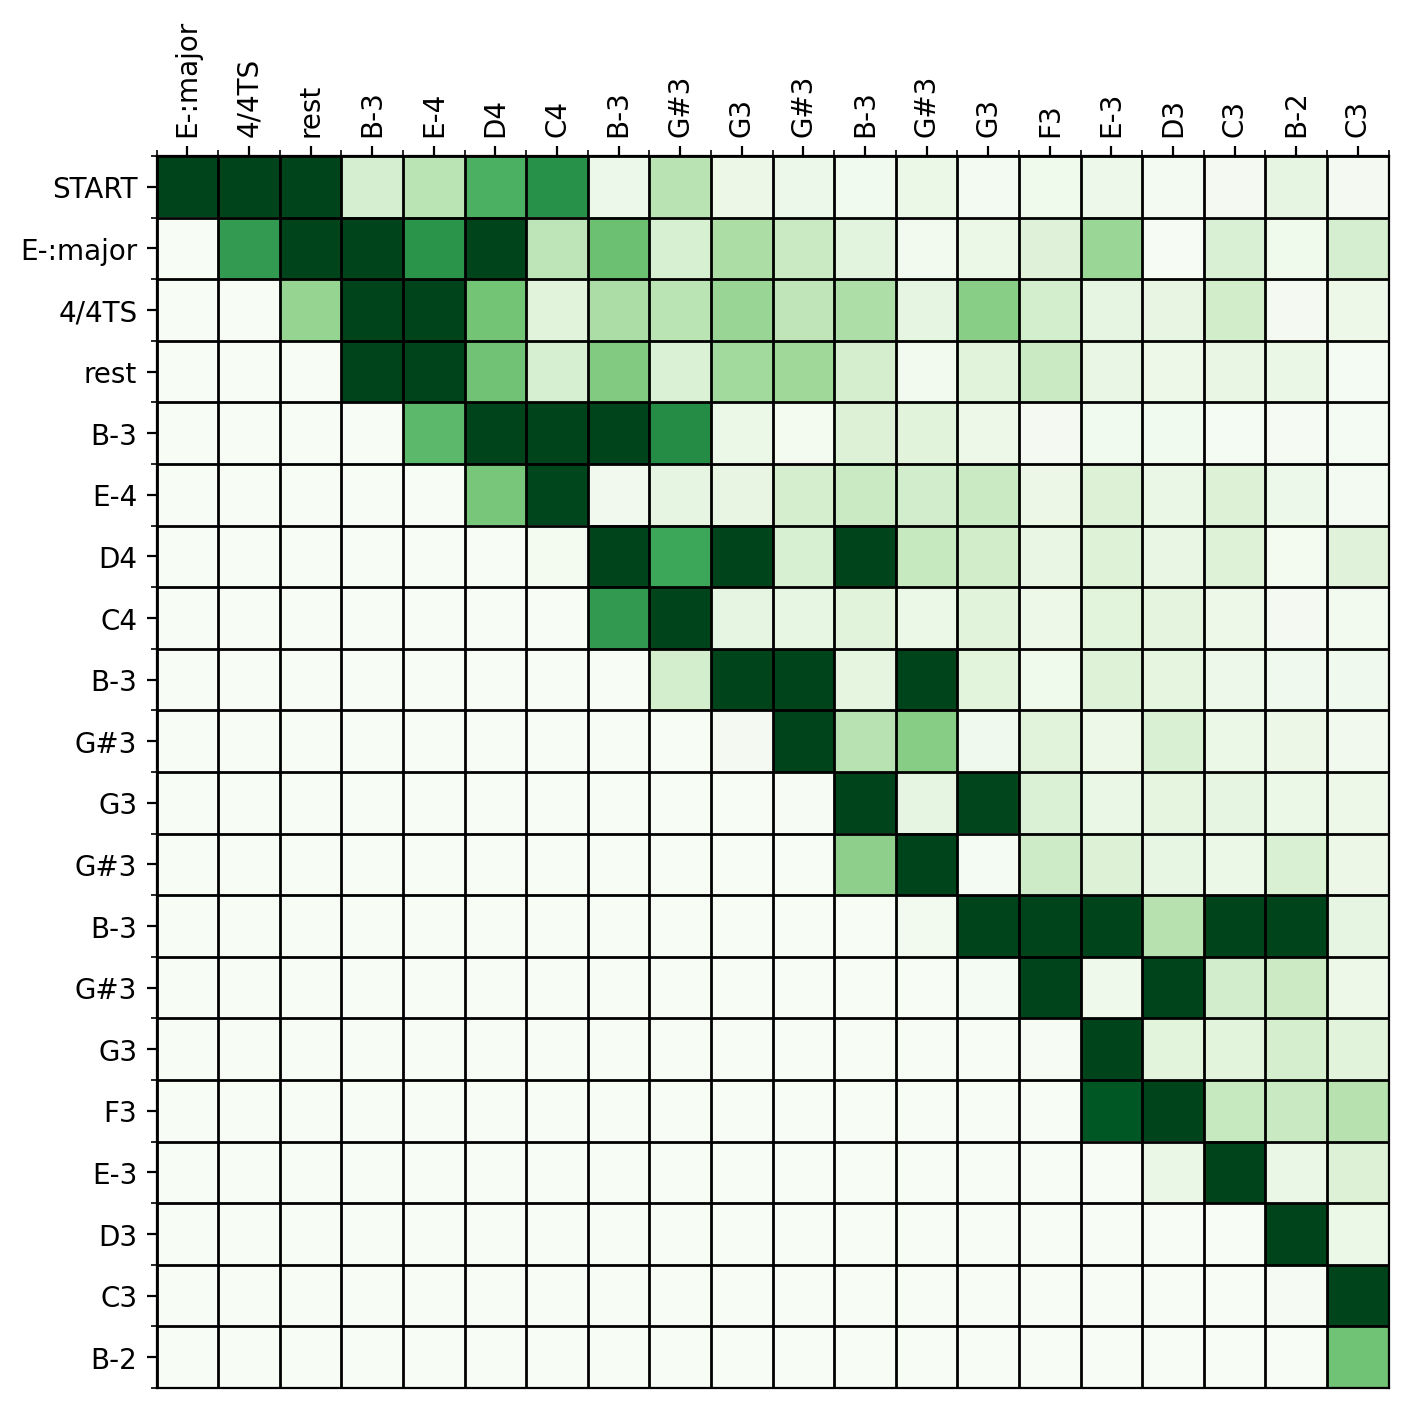

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(att_matrix, cmap="Greens", interpolation="nearest")

ax.set_xticks(np.arange(-0.5, plot_size, 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_size, 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
ax.set_xticks(np.arange(plot_size))
ax.set_yticks(np.arange(plot_size))
ax.set_xticklabels(prediction_output[:plot_size])
ax.set_yticklabels(last_prompt[:plot_size])
ax.xaxis.tick_top()

plt.setp(
    ax.get_xticklabels(),
    rotation=90,
    ha="left",
    va="center",
    rotation_mode="anchor",
)
plt.show()